In [27]:
import numpy as np
import matplotlib.pyplot as plt
import collections
import ROOT as root
import awkward as ak
import uproot

In [2]:
#We can pull in our merged and unmerged hit data. The neutrino vertices array is common to both files.
data_unmerged = np.load('../hitwise_detector_sim_0002459.npz')
data_merged = np.load('../python/test_0002459_merged.npz')
neutrino_vertices = data_unmerged['first']
hit_array_unmerged = data_unmerged['second']
hit_array_merged = data_merged['first']
print(np.shape(hit_array_unmerged))
print(np.shape(hit_array_merged))

(252256, 7)
(107479, 8)


In [3]:
#Some useful sorting functions
def SortByTime(array):
    sorted_array = array[np.argsort(array[:,5])]
    return(sorted_array)

def SortByNN(array):
    sorted_array = array[np.argsort(array[:,0])]
    return(sorted_array)

sorted_hits_merged = SortByTime(hit_array_merged)
sorted_hits_unmerged = SortByTime(hit_array_unmerged)

In [4]:
#A useful data structure that can serve as a test of energy efficiency. This array stores total hits and total PEs for neutrino numbers

# | neutrino number | total PEs | total hits |

#Patched from initial development as there was an extra row and a kinda useless conditional

#Creates this array using unmerged PEs
neutrino_PE_array_merged = np.zeros((5978, 3))
for i in range(5978):
    PEs = 0.
    sub_array = sorted_hits_merged[sorted_hits_merged[:, 0] == i]
    n_hits = 0
    for hit in sub_array:
        n_hits += 1
        PEs += hit[6]
    neutrino_PE_array_merged[i][0] = i
    neutrino_PE_array_merged[i][1] = PEs
    neutrino_PE_array_merged[i][2] = n_hits

#print(neutrino_PE_array_merged)

#do a quick check of PE balance. 
#if (np.sum(neutrino_PE_array_merged[:,1]) != np.sum(neutrino_PE_array_unmerged[:,1])):
#    print("Warning, merged total PE != unmerged total PE")

In [5]:
#A time slicer based on the principles of the dune-tms slicer. takes thresholds and a hits array. I think this is working as intended. 
#This function will return a list of lists of arrays. lol
#Patched to stop adding the hit after energy drops below threshold

def SimpleTimeSlicer(hits, initial_threshold_energy=50, drop_threshold_energy=40):
    sorted_hits = SortByTime(hits)
    events = []  # This object stores the final "events" or slices that are grouped by the algorithm
    window_duration_ns = 19

    current_window_hits = collections.deque()
    current_window_energy_sum = 0.0

    in_accumulation_phase = False
    current_event_hits = []  # Stores hit info for our event that is accumulating

    for hit_row in sorted_hits:  # Iterate through each full hit row
        hit_time = hit_row[5]    # Time is at index 5
        hit_energy = hit_row[6]  # Energy is at index 6

        # Add the current full hit row to the window
        current_window_hits.append(hit_row)  # Store the entire row
        current_window_energy_sum += hit_energy  # Add the hit energy to our current window

        # Remove hits that are outside the current window, basically sliding the deque forward
        # The window is defined by (current_hit_time - window_duration_ns, current_hit_time]
        while current_window_hits and current_window_hits[0][5] <= hit_time - window_duration_ns:
            # This loop removes all hits from the front of the window that are outside 
            # the time range (older than hit_time - window_duration_ns)
            oldest_hit_row = current_window_hits.popleft()  # Get the full oldest row
            oldest_hit_energy = oldest_hit_row[6]  # Access energy from the row
            current_window_energy_sum -= oldest_hit_energy

        # Handle accumulation logic
        if not in_accumulation_phase:
            # Not in accumulation, if we pass the threshold we should start
            if current_window_energy_sum >= initial_threshold_energy:
                in_accumulation_phase = True  # Here we activate accumulation mode - begin a slice.
                # When we *start* accumulation, initialize `current_event_hits` with
                # all hits currently within the *valid* window (i.e., those in `current_window_hits`).
                # We need to make a copy here (`list(...)`) because `current_window_hits`
                # will continue to change as the window slides.
                # This making a copy rather than grabbing it every time the hit slides 
                # was the reason we encountered duplicates in previous versions
                current_event_hits = list(current_window_hits)
        else:
            # We ARE currently in an accumulation phase
            # Check if the energy in the *current window* has dropped below the threshold,
            # BEFORE adding the most recent hit to the accumulating event
            if current_window_energy_sum < drop_threshold_energy:
                # If indeed we have dropped below threshold, go ahead and 
                events.append(current_event_hits)
                in_accumulation_phase = False  # Turning off accumulation mode
                current_event_hits = []  # Reset for the next event - dumping the current event's hit list
            else:
                # Still above threshold, so include the current hit
                current_event_hits.append(hit_row)

    # After iterating through all hits, check if we were still in an accumulation phase.
    # If so, the last event needs to be saved, it won't do this automatically!
    if in_accumulation_phase:
        events.append(current_event_hits)

    return events

In [6]:
#Some other utility functions

#this function checks how many total events were placed into groups. 
def ValidateEvents(events, hit_array_merged):
    hits_sliced = 0
    for group in events:
        for hit in group:
            hits_sliced += 1
    missing = (np.shape(hit_array_merged)[0] - hits_sliced)
    missing_ratio = missing / np.shape(hit_array_merged)[0]
    #print(f"Grouped {hits_sliced} hits into {len(events)} slices, {missing} hits were not grouped, {(missing_ratio * 100):2f}% of total")
    return(hits_sliced, missing, missing_ratio)

#this function will return a list of hits grouped into arrays based on their event. May incorporate into main function...
#then individual slices can be accessed by their index. 
def StackEvents(events):
    event_list = []
    for i in range(len(events)):
        event_list.append(np.vstack(events[i]))
    return(event_list)
            
#This function can print out the time slices
def SlicerPrinting(events, loud = False):
    print(f"Detected {len(events)} slices:")
    for i, event in enumerate(events):
        print(f"\n--- Event {i+1} ---")
        total_energy_event = sum(hit_row[6] for hit_row in event) # Sum energy from full rows
        print(f"Total hits: {len(event)}")
        print(f"Total energy: {total_energy_event:.2f}")
        # Get min/max time from the full hit rows in the event
        if event: # Ensure event is not empty before accessing elements
            start_time = min(hit_row[5] for hit_row in event)
            end_time = max(hit_row[5] for hit_row in event)
            print(f"Time range: {start_time:.1f} ns - {end_time:.1f} ns")
            print(f"Total time: {(end_time - start_time):.2f} ns")
            
        if loud:
            print("Hits (full data) in event:")
            for hit_row in event:
                # Print specific fields for clarity, or the whole row
                print(f"  Neutrino: {hit_row[0]}, Hit: {hit_row[1]}, Time: {hit_row[5]:.1f}, Energy: {hit_row[6]:.1f}, X: {hit_row[2]}")

def TimePlot(events, slices_to_grab, init_thresh, drop_thresh):
    slice_stack = StackEvents(events)
    slices_grabbed = slice_stack[:slices_to_grab]
    for time_slice in slices_grabbed:
        plt.hist(time_slice[:,5])

    plt.title(f"First {slices_to_grab} Slices - Init Thresh {init_thresh} PE, Drop Thresh {drop_thresh} PE ")
    plt.xlabel("Hit Time (ns)")
    plt.ylabel("# hits")
    plt.show()

In [7]:
def SliceEvaluate(events):
    slice_stack = StackEvents(events)
    #make sure you are careful about how assigning here, 
    containment_array = np.zeros((5978,5))
    #containment_array = np.full((5978,5), -1.) #here, I am assigning -1, will tell us if the neutrino event is just never picked up by the slicer. 
    #if we filled with zeroes could mistake for something that was picked up but at very low efficiency %, a different thing!!

    containment_array = np.zeros((5978,5)) #|nn | hit containment | PE containment | best hit containment slice | best PE containment slice |
    purity_array = np.zeros((len(slice_stack),2))

    for i in range(5978):
        containment_array[i][0] = i

    for j in range(len(slice_stack)):
        slice_number = j
        selected_slice = slice_stack[j]
        nns = selected_slice[:,0] #grab the neutrino numbers
        nns_represented, counts = np.unique(nns, return_counts = True) #counts can be used to determine the hit containment, need to loop for PEs

        #fill purity array
        purity_array[slice_number][0] = slice_number
        purity_array[slice_number][1] = len(nns_represented) #fill our purity array with number of unique neutrino numbers in the slice. 
    
        for i, nn in enumerate(nns_represented):
            total_hits = neutrino_PE_array_merged[int(nn)][2] #total hits
            total_PEs = neutrino_PE_array_merged[int(nn)][1] #total PE
            hits_in_slice = counts[i] #hits in this slice
            filtered_rows = (slice_stack[slice_number][slice_stack[slice_number][:, 0] == nn]) #grab subarray of rows with our hits
            PEs_in_slice = np.sum(filtered_rows[:,6]) #sum all the PEs for this nn in the slice. 
        
            containment_array[int(nn)][0] = nn #neutrino_number
        
            if (containment_array[int(nn)][1]) <= (hits_in_slice / total_hits) :
                containment_array[int(nn)][1] = hits_in_slice / total_hits #hits contained
                containment_array[int(nn)][3] = slice_number

            if (containment_array[int(nn)][2]) <= (PEs_in_slice / total_PEs) :
                containment_array[int(nn)][2] = PEs_in_slice / total_PEs #PEs contained
                containment_array[int(nn)][4] = slice_number #this slice. 

    #Create a masked version of the array
    neutrinos_with_TMS_hits = np.where(neutrino_PE_array_merged[:, 2] != 0)[0] #check that number of hits is non-zero
    masked_containment_array = containment_array[neutrinos_with_TMS_hits]

    #return containment, masked containment, and purity. 
    return(containment_array, masked_containment_array, purity_array)
    

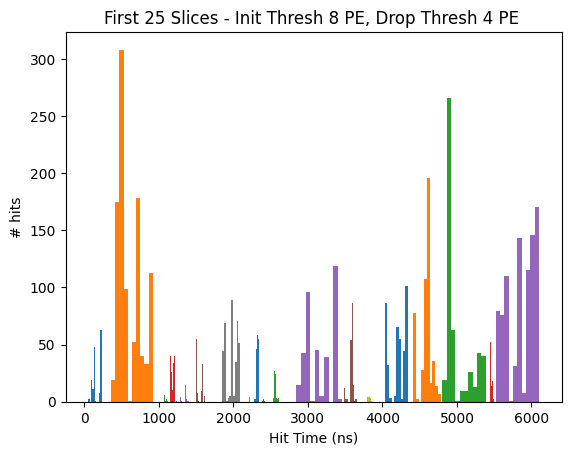

In [8]:
#Here is where we can run the time slicer and then validate:
init_thresh = 8
drop_thresh = 4
sliced = SimpleTimeSlicer(hit_array_merged, initial_threshold_energy = init_thresh, drop_threshold_energy = drop_thresh) #15, 7
put_in_slices, no_in_slices, frac_not_in_slices = ValidateEvents(sliced, hit_array_merged)
TimePlot(sliced, 25, init_thresh, drop_thresh)

[206  44]
[345  41]
[396  34]
[200  32]
[489  31]
[98 30]
[507  29]
[256  29]
[230  29]
[253  28]
[34 28]
[264  28]
[238  28]
[425  28]
[426  27]


Text(0.5, 1.0, 'Time Slice 43 Pileup Display, 7 Neutrino Events ')

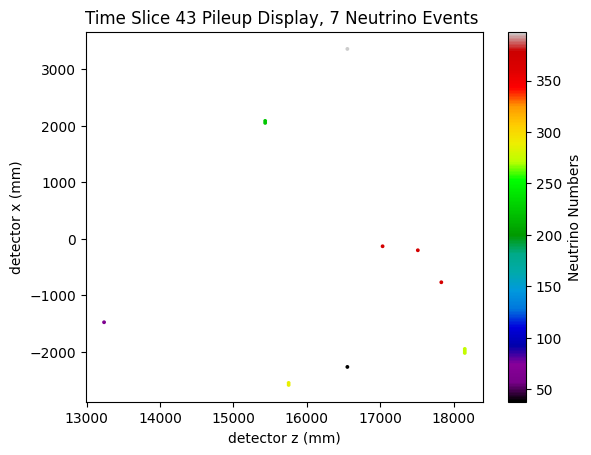

In [10]:
containment_array, masked_containment_array, purity_array = SliceEvaluate(sliced)
selected_slice = 43
slice_stack = StackEvents(sliced)

#lets find the most populated slices:
occupancy = []
for i, time_slice in enumerate(slice_stack):
    nns = time_slice[:,0]
    uniques = len(np.unique(nns))
    occupancy.append((np.array((i, uniques))))
occupancy_array = np.vstack(occupancy)
ascending_array = occupancy_array[np.argsort(occupancy_array[:,1])]
descending_array = ascending_array[::-1]
for i in range(15):
    print(descending_array[i])

#print(slice_stack[selected_event][1])
nns = slice_stack[selected_slice][:,0]
hit_xs = slice_stack[selected_slice][:,2]
hit_zs = slice_stack[selected_slice][:,4]
pileup = len(np.unique(nns))
plt.scatter(hit_zs, hit_xs, c = nns, s = 3, cmap = 'nipy_spectral')
plt.colorbar(label='Neutrino Numbers')
plt.xlabel("detector z (mm)")
plt.ylabel("detector x (mm)")
plt.title(f"Time Slice {selected_slice} Pileup Display, {pileup} Neutrino Events ")

In [49]:
#|Collective Neutrino #|Collective Hit #|Bar x|Bar y|Bar z|Total PE|Bar Orientation Code|File Number|constitutent hit_indexes#
column_names = ["neutrino number", "hit number", "hit x", "hit y", "hit z", "hit time", "hit PE", "bar orientation" ]
records_per_event = [
    [dict(zip(column_names, row)) for row in arr]
    for arr in slice_stack
]

#records_per_event[0]

#print(slice_stack[0][0])
awk_array = ak.Array(records_per_event)
#print(ak.type(awk_array))


test_file = uproot.open('/sdf/data/neutrino/summer25/ktwall/tms_timing/time_sliced/file_2459_sliced_init-8.0_drop-4.0.root')
test_file['Time Slices'].arrays()[0]['neutrino number']
test_file['Metrics']

<TTree 'Metrics' (8 branches) at 0x7f062b3f4c70>

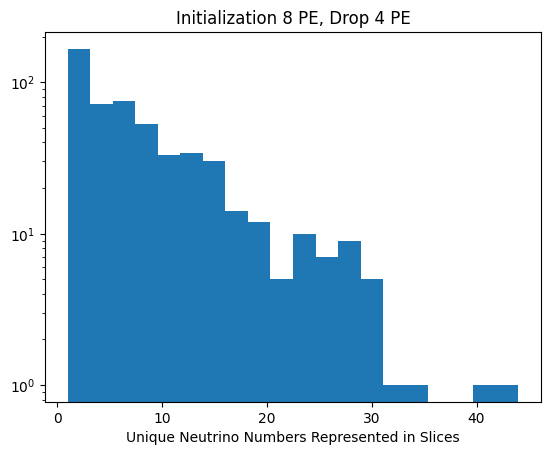

In [13]:
plt.hist(occupancy_array[:,1], bins=20)
plt.title("Initialization 8 PE, Drop 4 PE")
plt.xlabel("Unique Neutrino Numbers Represented in Slices")
plt.yscale('log')

In [19]:
#let's not consider neutrino events that are not grouped at all!
selected_events_array = masked_containment_array[masked_containment_array[:,1] != -1]
avg_hit_eff = np.mean(selected_events_array[:,1])
avg_PE_eff = np.mean(selected_events_array[:,2])
print(avg_hit_eff)
print(avg_PE_eff)

0.9274566789569624
0.951223222945576


In [163]:
#Full time slicing evaluation. 
init_thresh_range = range(8,9)#range(3, 100)
#drop_thresh_range = range(4,26)#range(0, 100)
array_list = []
for init_thresh in init_thresh_range:
    drop_thresh_range = range(4, 5) 
    for drop_thresh in drop_thresh_range:
        #run slicing
        sliced = SimpleTimeSlicer(hit_array_merged, initial_threshold_energy = init_thresh, drop_threshold_energy = drop_thresh)
        containment_array, masked_containment_array, purity_array = SliceEvaluate(sliced)
        put_in_slices, not_in_slices, frac_not_in_slices = ValidateEvents(sliced, hit_array_merged)
        #metrics
        avg_PE_eff = np.mean(masked_containment_array[:,2])
        avg_hit_eff = np.mean(masked_containment_array[:,1])
        avg_purity = np.mean(purity_array[:,1])
        missing = not_in_slices
        n_slices = len(sliced)
        
        metric_array = np.array((init_thresh, drop_thresh, avg_PE_eff, avg_hit_eff, avg_purity, missing, n_slices))
        array_list.append(metric_array)
    print(f"processed init {init_thresh}")

metric_stack = np.vstack(array_list)
np.savez('metric_stack_init_8_drop_4.npz', first = metric_stack)       

processed init 8


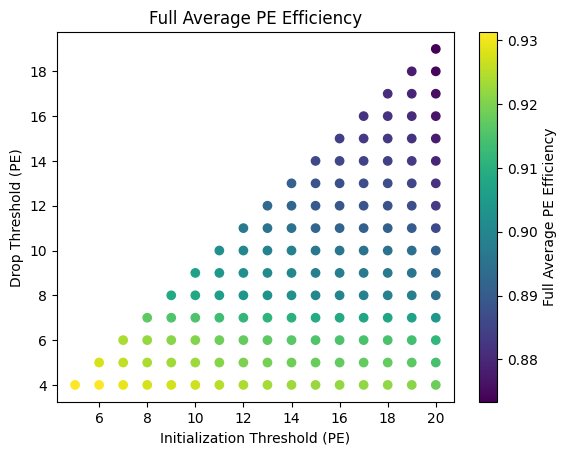

In [124]:
metric_stack = np.load("metric_stack_init_5_20.npz")['first']
init_thresholds = metric_stack[:,0]
drop_thresholds = metric_stack[:,1]
PE_efficiency = metric_stack[:,2]
plt.scatter(init_thresholds, drop_thresholds, c = PE_efficiency, cmap = 'viridis')
plt.colorbar(label='Full Average PE Efficiency')
plt.xlabel("Initialization Threshold (PE)")
plt.ylabel("Drop Threshold (PE)")
plt.title("Full Average PE Efficiency")
plt.show()

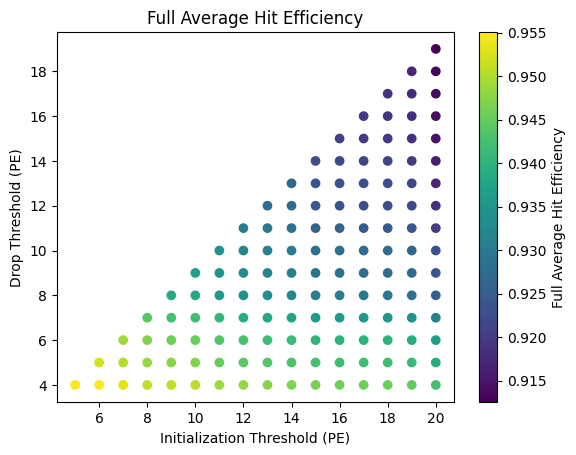

In [125]:
init_thresholds = metric_stack[:,0]
drop_thresholds = metric_stack[:,1]
hit_efficiency = metric_stack[:,3]
plt.scatter(init_thresholds, drop_thresholds, c = hit_efficiency, cmap = 'viridis')
plt.colorbar(label='Full Average Hit Efficiency')
plt.xlabel("Initialization Threshold (PE)")
plt.ylabel("Drop Threshold (PE)")
plt.title("Full Average Hit Efficiency")
plt.show()

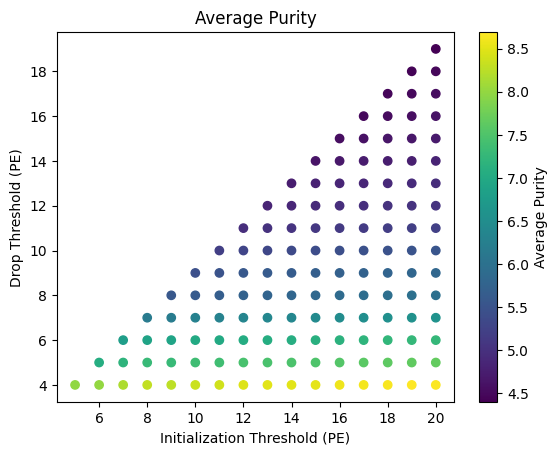

In [126]:
init_thresholds = metric_stack[:,0]
drop_thresholds = metric_stack[:,1]
avg_purity = metric_stack[:,4]
plt.scatter(init_thresholds, drop_thresholds, c = avg_purity, cmap = 'viridis')
plt.colorbar(label='Average Purity')
plt.xlabel("Initialization Threshold (PE)")
plt.ylabel("Drop Threshold (PE)")
plt.title("Average Purity")
plt.show()

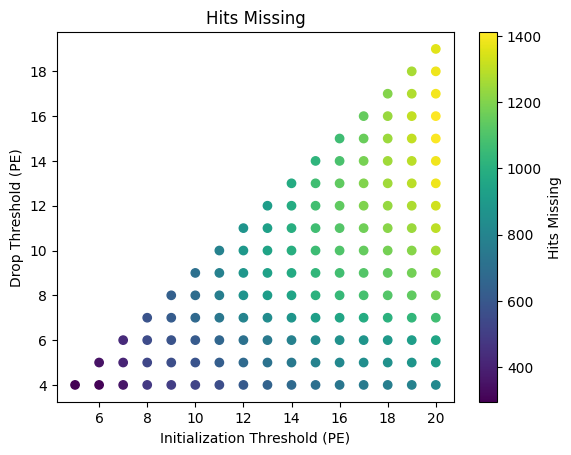

In [128]:
init_thresholds = metric_stack[:,0]
drop_thresholds = metric_stack[:,1]
hits_missing = metric_stack[:,5]
plt.scatter(init_thresholds, drop_thresholds, c = hits_missing, cmap = 'viridis')
plt.colorbar(label='Hits Missing')
plt.xlabel("Initialization Threshold (PE)")
plt.ylabel("Drop Threshold (PE)")
plt.title("Hits Missing")
plt.show()

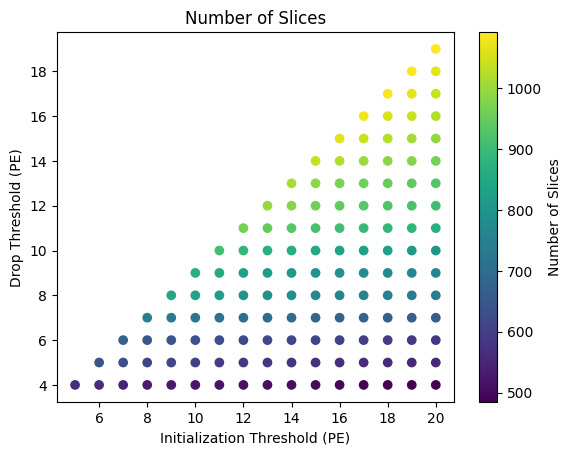

In [129]:
init_thresholds = metric_stack[:,0]
drop_thresholds = metric_stack[:,1]
number_slices = metric_stack[:,6]
plt.scatter(init_thresholds, drop_thresholds, c = number_slices, cmap = 'viridis')
plt.colorbar(label='Number of Slices')
plt.xlabel("Initialization Threshold (PE)")
plt.ylabel("Drop Threshold (PE)")
plt.title("Number of Slices")
plt.show()

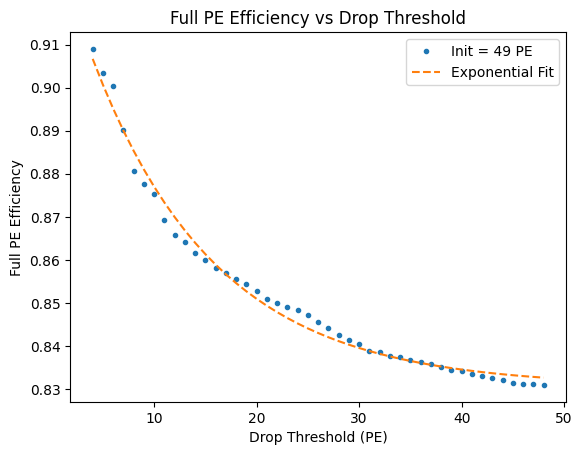

f(x) = (a * np.exp(-b * x)) + c 
a = 0.106(0.002), b = 0.083(0.004), c = 0.831(0.001)


In [74]:
from scipy.optimize import curve_fit

#exponential
def exp_func(x,a,b,c):
    y = (a * np.exp(-b * x)) + c
    return(y)

trimmed_metric_stack_49 = metric_stack[metric_stack[:, 0] == 49]
drop_thresholds_49 = trimmed_metric_stack_49[:,1]
PE_efficiency_49 = trimmed_metric_stack_49[:,2]

#fit
popt, pcov = curve_fit(exp_func, drop_thresholds_49, PE_efficiency_49)
perr = np.sqrt(np.diag(pcov))

plt.plot(drop_thresholds_49, PE_efficiency_49, '.', label = "Init = 49 PE")
plt.plot(drop_thresholds_49, exp_func(drop_thresholds_49, popt[0], popt[1], popt[2]), label = "Exponential Fit", linestyle='dashed')
plt.xlabel("Drop Threshold (PE)")
plt.ylabel("Full PE Efficiency")
plt.title("Full PE Efficiency vs Drop Threshold")
plt.legend()
plt.show()

print(f"f(x) = (a * np.exp(-b * x)) + c ")
print(f'a = {popt[0]:.3f}({perr[0]:.3f}), b = {popt[1]:.3f}({perr[1]:.3f}), c = {popt[2]:.3f}({perr[2]:.3f})')

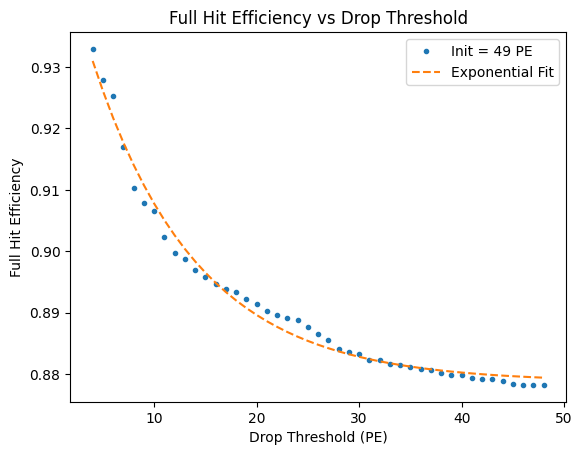

f(x) = (a * np.exp(-b * x)) + c 
a = 0.077(0.002), b = 0.098(0.004), c = 0.879(0.001)


In [75]:
def exp_func(x,a,b,c):
    y = (a * np.exp(-b * x)) + c
    return(y)

trimmed_metric_stack_49 = metric_stack[metric_stack[:, 0] == 49]
drop_thresholds_49 = trimmed_metric_stack_49[:,1]
hit_efficiency_49 = trimmed_metric_stack_49[:,3]

#fit
popt, pcov = curve_fit(exp_func, drop_thresholds_49, hit_efficiency_49)
perr = np.sqrt(np.diag(pcov))

plt.plot(drop_thresholds_49, hit_efficiency_49, '.', label = "Init = 49 PE")
plt.plot(drop_thresholds_49, exp_func(drop_thresholds_49, popt[0], popt[1], popt[2]), label = "Exponential Fit", linestyle='dashed')
plt.xlabel("Drop Threshold (PE)")
plt.ylabel("Full Hit Efficiency")
plt.title("Full Hit Efficiency vs Drop Threshold")
plt.legend()
plt.show()

print(f"f(x) = (a * np.exp(-b * x)) + c ")
print(f'a = {popt[0]:.3f}({perr[0]:.3f}), b = {popt[1]:.3f}({perr[1]:.3f}), c = {popt[2]:.3f}({perr[2]:.3f})')

/lscratch/ktwall/tmp/ipykernel_452631/1197088857.py:6: RuntimeWarning: overflow encountered in exp
  y = (a * np.exp(-b * x)) + c


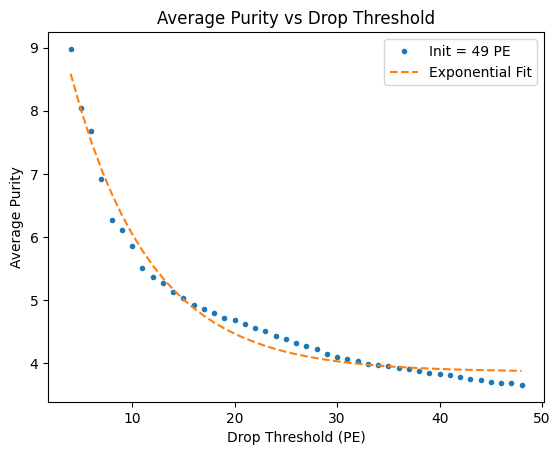

f(x) = (a * np.exp(-b * x)) + c 
a = 7.890(0.321), b = 0.129(0.006), c = 3.865(0.045)


In [76]:
trimmed_metric_stack_49 = metric_stack[metric_stack[:, 0] == 49]
drop_thresholds_49 = trimmed_metric_stack_49[:,1]
avg_purity_49 = trimmed_metric_stack_49[:,4]

def exp_func(x,a,b,c):
    y = (a * np.exp(-b * x)) + c
    return(y)

popt, pcov = curve_fit(exp_func, drop_thresholds_49, avg_purity_49)
perr = np.sqrt(np.diag(pcov))

plt.plot(drop_thresholds_49, avg_purity_49, '.', label = "Init = 49 PE")
plt.plot(drop_thresholds_49, exp_func(drop_thresholds_49, popt[0], popt[1], popt[2]), label = "Exponential Fit", linestyle='dashed')
plt.xlabel("Drop Threshold (PE)")
plt.ylabel("Average Purity")
plt.title("Average Purity vs Drop Threshold")
plt.legend()
plt.show()

print(f"f(x) = (a * np.exp(-b * x)) + c ")
print(f'a = {popt[0]:.3f}({perr[0]:.3f}), b = {popt[1]:.3f}({perr[1]:.3f}), c = {popt[2]:.3f}({perr[2]:.3f})')

/lscratch/ktwall/tmp/ipykernel_452631/1357059213.py:6: RuntimeWarning: overflow encountered in exp
  y = (a * np.exp(-b * x)) + c


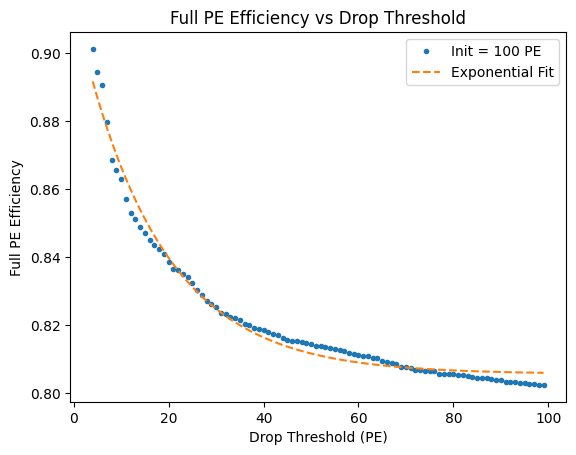

f(x) = (a * np.exp(-b * x)) + c 
a = 0.109(0.002), b = 0.058(0.002), c = 0.806(0.001)


In [77]:
#can look at the straight shot ones now.
from scipy.optimize import curve_fit

#exponential
def exp_func(x,a,b,c):
    y = (a * np.exp(-b * x)) + c
    return(y)

#import 
long_shot_metrics = np.load("metric_stack_init_100_101.npz")['first']
drop_thresh = long_shot_metrics[:,1]
PE_efficiency = long_shot_metrics[:,2]

#fit
popt, pcov = curve_fit(exp_func, drop_thresh, PE_efficiency)
perr = np.sqrt(np.diag(pcov))

plt.plot(drop_thresh, PE_efficiency, '.', label = "Init = 100 PE")
plt.plot(drop_thresh, exp_func(drop_thresh, popt[0], popt[1], popt[2]), label = "Exponential Fit", linestyle='dashed')
plt.xlabel("Drop Threshold (PE)")
plt.ylabel("Full PE Efficiency")
plt.title("Full PE Efficiency vs Drop Threshold")
plt.legend()
plt.show()

print(f"f(x) = (a * np.exp(-b * x)) + c ")
print(f'a = {popt[0]:.3f}({perr[0]:.3f}), b = {popt[1]:.3f}({perr[1]:.3f}), c = {popt[2]:.3f}({perr[2]:.3f})')

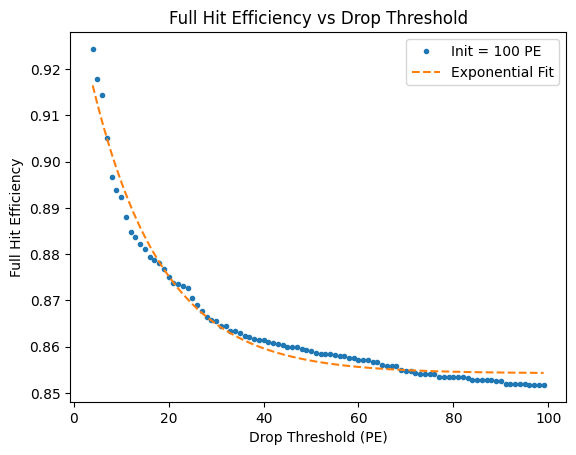

f(x) = (a * np.exp(-b * x)) + c 
a = 0.082(0.002), b = 0.068(0.002), c = 0.854(0.000)


In [78]:
#can look at the straight shot ones now.
from scipy.optimize import curve_fit

#exponential
def exp_func(x,a,b,c):
    y = (a * np.exp(-b * x)) + c
    return(y)

#import 
long_shot_metrics = np.load("metric_stack_init_100_101.npz")['first']
drop_thresh = long_shot_metrics[:,1]
hit_efficiency = long_shot_metrics[:,3]

#fit
popt, pcov = curve_fit(exp_func, drop_thresh, hit_efficiency)
perr = np.sqrt(np.diag(pcov))

plt.plot(drop_thresh, hit_efficiency, '.', label = "Init = 100 PE")
plt.plot(drop_thresh, exp_func(drop_thresh, popt[0], popt[1], popt[2]), label = "Exponential Fit", linestyle='dashed')
plt.xlabel("Drop Threshold (PE)")
plt.ylabel("Full Hit Efficiency")
plt.title("Full Hit Efficiency vs Drop Threshold")
plt.legend()
plt.show()

print(f"f(x) = (a * np.exp(-b * x)) + c ")
print(f'a = {popt[0]:.3f}({perr[0]:.3f}), b = {popt[1]:.3f}({perr[1]:.3f}), c = {popt[2]:.3f}({perr[2]:.3f})')

/lscratch/ktwall/tmp/ipykernel_452631/3799891181.py:6: RuntimeWarning: overflow encountered in exp
  y = (a * np.exp(-b * x)) + c


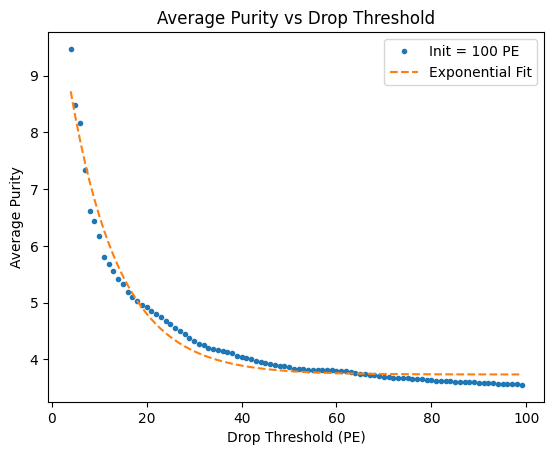

f(x) = (a * np.exp(-b * x)) + c 
a = 7.333(0.225), b = 0.096(0.003), c = 3.733(0.025)


In [79]:
#can look at the straight shot ones now.
from scipy.optimize import curve_fit

#exponential
def exp_func(x,a,b,c):
    y = (a * np.exp(-b * x)) + c
    return(y)

#import 
long_shot_metrics = np.load("metric_stack_init_100_101.npz")['first']
drop_thresh = long_shot_metrics[:,1]
avg_purity = long_shot_metrics[:,4]

#fit
popt, pcov = curve_fit(exp_func, drop_thresh, avg_purity)
perr = np.sqrt(np.diag(pcov))

plt.plot(drop_thresh, avg_purity, '.', label = "Init = 100 PE")
plt.plot(drop_thresh, exp_func(drop_thresh, popt[0], popt[1], popt[2]), label = "Exponential Fit", linestyle='dashed')
plt.xlabel("Drop Threshold (PE)")
plt.ylabel("Average Purity")
plt.title("Average Purity vs Drop Threshold")
plt.legend()
plt.show()

print(f"f(x) = (a * np.exp(-b * x)) + c ")
print(f'a = {popt[0]:.3f}({perr[0]:.3f}), b = {popt[1]:.3f}({perr[1]:.3f}), c = {popt[2]:.3f}({perr[2]:.3f})')

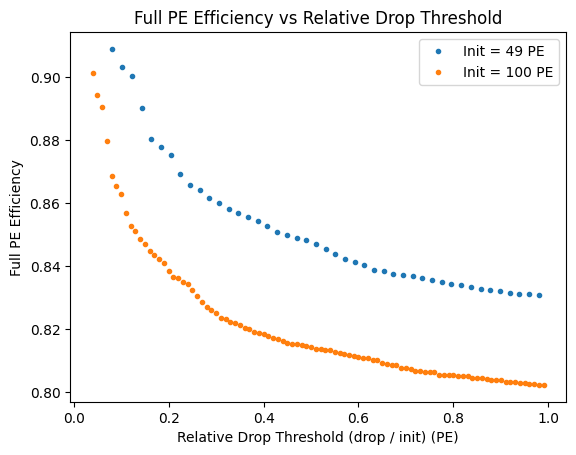

In [80]:
from scipy.optimize import curve_fit
metric_stack = np.load("metric_stack_init_4_50.npz")['first']
trimmed_metric_stack_49 = metric_stack[metric_stack[:, 0] == 49]

#exponential
def exp_func(x,a,b,c):
    y = (a * np.exp(-b * x)) + c
    return(y)

trimmed_metric_stack_49 = metric_stack[metric_stack[:, 0] == 49]
drop_thresholds_49 = trimmed_metric_stack_49[:,1] / 49.
PE_efficiency_49 = trimmed_metric_stack_49[:,2]

long_shot_metrics = np.load("metric_stack_init_100_101.npz")['first']
drop_thresholds_100 = long_shot_metrics[:,1] / 100.
PE_efficiency_100 = long_shot_metrics[:,2]

#fit
#popt, pcov = curve_fit(exp_func, drop_thresholds_49, PE_efficiency_49)
#perr = np.sqrt(np.diag(pcov))

plt.plot(drop_thresholds_49, PE_efficiency_49, '.', label = "Init = 49 PE")
plt.plot(drop_thresholds_100, PE_efficiency_100, '.', label = "Init = 100 PE") 
#plt.plot(drop_thresholds_49, exp_func(drop_thresholds_49, popt[0], popt[1], popt[2]), label = "Exponential Fit", linestyle='dashed')
plt.xlabel("Relative Drop Threshold (drop / init) (PE)")
plt.ylabel("Full PE Efficiency")
plt.title("Full PE Efficiency vs Relative Drop Threshold")
plt.legend()
plt.show()

#print(f"f(x) = (a * np.exp(-b * x)) + c ")
#print(f'a = {popt[0]:.3f}({perr[0]:.3f}), b = {popt[1]:.3f}({perr[1]:.3f}), c = {popt[2]:.3f}({perr[2]:.3f})')

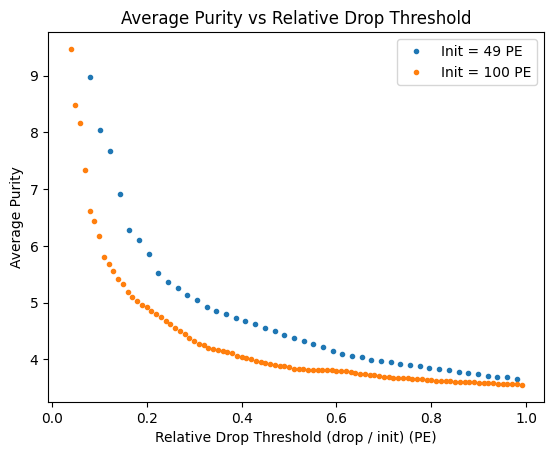

In [81]:
from scipy.optimize import curve_fit
metric_stack = np.load("metric_stack_init_4_50.npz")['first']
trimmed_metric_stack_49 = metric_stack[metric_stack[:, 0] == 49]

#exponential
def exp_func(x,a,b,c):
    y = (a * np.exp(-b * x)) + c
    return(y)

trimmed_metric_stack_49 = metric_stack[metric_stack[:, 0] == 49]
drop_thresholds_49 = trimmed_metric_stack_49[:,1] / 49.
avg_purity_49 = trimmed_metric_stack_49[:,4]

long_shot_metrics = np.load("metric_stack_init_100_101.npz")['first']
drop_thresholds_100 = long_shot_metrics[:,1] / 100.
avg_purity_100 = long_shot_metrics[:,4]

#fit
#popt, pcov = curve_fit(exp_func, drop_thresholds_49, PE_efficiency_49)
#perr = np.sqrt(np.diag(pcov))

plt.plot(drop_thresholds_49, avg_purity_49, '.', label = "Init = 49 PE")
plt.plot(drop_thresholds_100, avg_purity_100, '.', label = "Init = 100 PE") 
#plt.plot(drop_thresholds_49, exp_func(drop_thresholds_49, popt[0], popt[1], popt[2]), label = "Exponential Fit", linestyle='dashed')
plt.xlabel("Relative Drop Threshold (drop / init) (PE)")
plt.ylabel("Average Purity")
plt.title("Average Purity vs Relative Drop Threshold")
plt.legend()
plt.show()

#print(f"f(x) = (a * np.exp(-b * x)) + c ")
#print(f'a = {popt[0]:.3f}({perr[0]:.3f}), b = {popt[1]:.3f}({perr[1]:.3f}), c = {popt[2]:.3f}({perr[2]:.3f})')

In [89]:
#Let's take a quick look at the average PE for temporily first hits in a given neutrino event
first_hit_PEs = [] 
for i in range(5978): #5978
    times = []
    sub_array = sorted_hits_merged[sorted_hits_merged[:, 0] == i]
    if len(sub_array) > 0:
        sorted_sub_array = SortByTime(sub_array)
        first_hit_PEs.append(sorted_sub_array[0][6]) #append the PE of the first hit. 

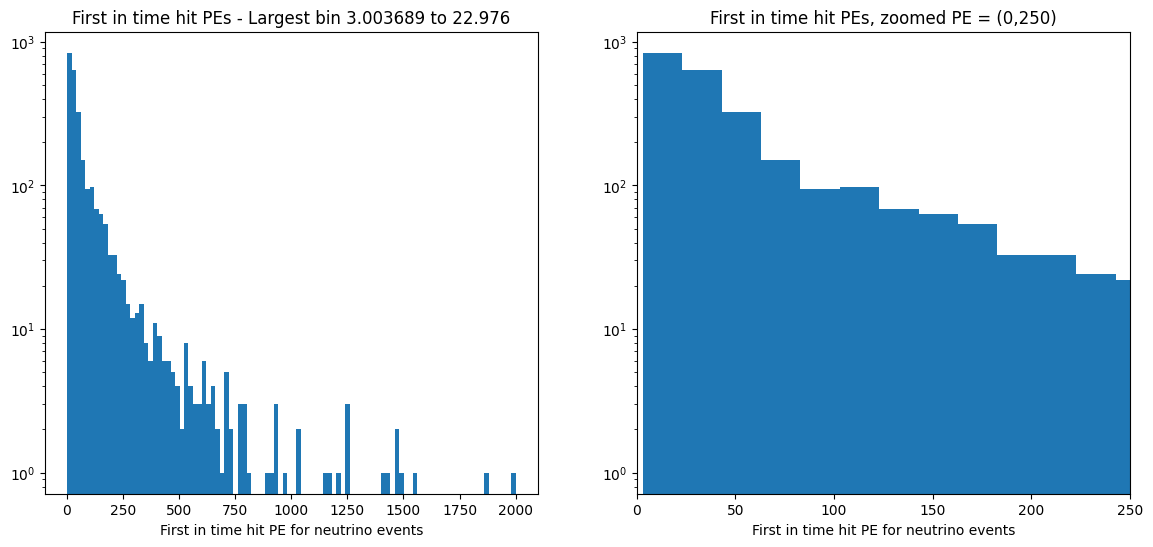

In [109]:
counts, bin_edges = np.histogram(first_hit_PEs, bins= 100)
most_counts_index = np.argmax(counts)
most_populated_bin_start = bin_edges[most_counts_index]
most_populated_bin_end = bin_edges[most_counts_index + 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.hist(first_hit_PEs, bins = 100)
ax1.set_yscale('log')
ax1.set_xlabel("First in time hit PE for neutrino events")
ax1.set_title(f"First in time hit PEs - Largest bin {most_populated_bin_start:1f} to {most_populated_bin_end:.3f}")

ax2.hist(first_hit_PEs, bins = 100)
ax2.set_xlim((0,250))
ax2.set_xlabel("First in time hit PE for neutrino events")
ax2.set_title(f"First in time hit PEs, zoomed PE = (0,250)")
ax2.set_yscale('log')

In [118]:
long_shot_metrics = np.load("metric_stack_init_100_101.npz")['first']
avg_PE_eff = long_shot_metrics[:,2]
avg_purity = long_shot_metrics[:,4]

#sqrt
def sqrt_func(x,a,c):
    y = a * np.sqrt((x)) + c
    return(y)

popt, pcov = curve_fit(sqrt_func, avg_purity, avg_PE_eff)
perr = np.sqrt(np.diag(pcov))


Text(0.5, 1.0, 'Average PE Efficiency vs Purity, init = 100, various drops')

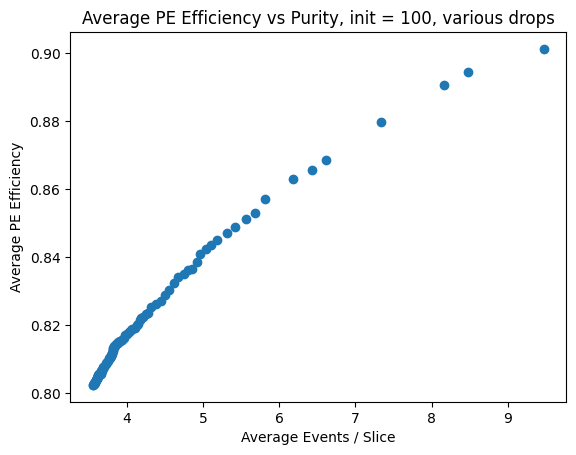

In [120]:

plt.scatter(avg_purity, avg_PE_eff)
plt.xlabel("Average Events / Slice")
plt.ylabel("Average PE Efficiency")
plt.title("Average PE Efficiency vs Purity, init = 100, various drops")

In [165]:
#Let's compare two candidate threshold sets. 8 and 4 and 10 and 5
metrics_8_4 = np.load('metric_stack_init_8_drop_4.npz')['first']
metrics_10_5 = np.load('metric_stack_init_10_drop_5.npz')['first']
print(metrics_8_4)
print(metrics_10_5)

[[  8.           4.           0.95122322   0.92745668   8.29111531
  479.         529.        ]]
[[ 10.           5.           0.94708246   0.92272252   7.35559265
  583.         599.        ]]
